# Simulação e pré-processamento de dados IoT

Este notebook gera uma série temporal sintética de temperatura e umidade, aplica interpolação para preencher dados faltantes, detecta outliers por meio de três desvios padrão e utiliza média móvel para suavização. Os resultados são exportados como gráfico e arquivo CSV para análise posterior.

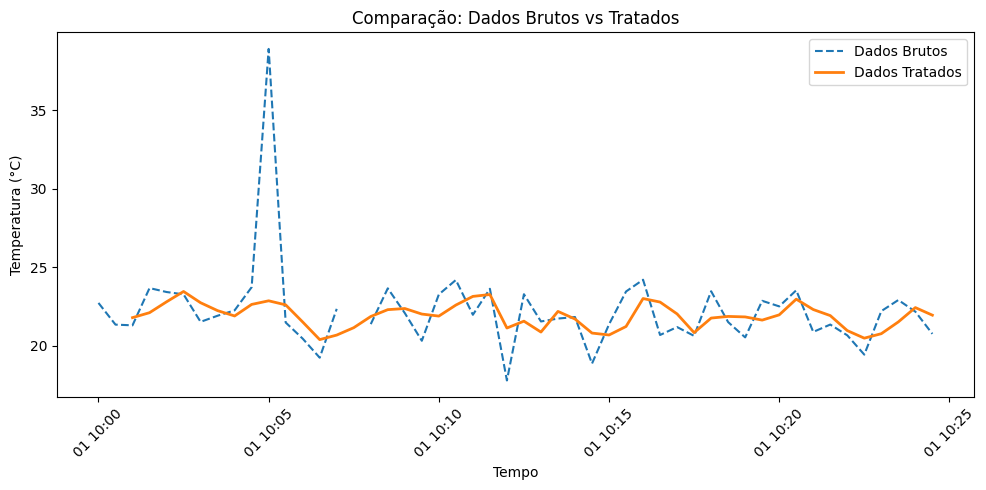

            timestamp  temperatura_bruta  temperatura_interp  \
0 2024-01-01 10:00:00          22.734483           22.734483   
1 2024-01-01 10:00:30          21.353244           21.353244   
2 2024-01-01 10:01:00          21.308461           21.308461   
3 2024-01-01 10:01:30          23.679029           23.679029   
4 2024-01-01 10:02:00          23.429423           23.429423   
5 2024-01-01 10:02:30          23.279852           23.279852   
6 2024-01-01 10:03:00          21.530780           21.530780   
7 2024-01-01 10:03:30          21.919899           21.919899   
8 2024-01-01 10:04:00          22.262158           22.262158   
9 2024-01-01 10:04:30          23.734598           23.734598   

   temperatura_limpa  temperatura_filtrada  
0          22.734483                   NaN  
1          21.353244                   NaN  
2          21.308461             21.798730  
3          23.679029             22.113578  
4          23.429423             22.805638  
5          23.279852     

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. GERAR DADOS SIMULADOS
# -----------------------------

np.random.seed(42)

# Criar timestamps
tempo = pd.date_range("2024-01-01 10:00:00", periods=50, freq="30s")

# Temperatura e umidade base
temperatura_base = 22 + np.random.normal(0, 0.5, len(tempo))
umidade_base = 48 + np.random.normal(0, 1.0, len(tempo))

# Adicionar ruído extra
temperatura_ruido = temperatura_base + np.random.normal(0, 1.5, len(tempo))
umidade_ruido = umidade_base + np.random.normal(0, 2.0, len(tempo))

# Inserir outliers e dados faltantes
temperatura_ruido[10] = 38.9
umidade_ruido[20] = 70

temperatura_ruido[15] = np.nan
umidade_ruido[25] = np.nan

# Criar DataFrame
df = pd.DataFrame({
    "timestamp": tempo,
    "temperatura_bruta": temperatura_ruido,
    "umidade_bruta": umidade_ruido
})

# -----------------------------
# 2. PRÉ-PROCESSAMENTO
# -----------------------------

def detectar_outliers(series, n_std=3):
    media = series.mean()
    desvio = series.std()
    return (series - media).abs() > n_std * desvio

for campo in ["temperatura_bruta", "umidade_bruta"]:
    outlier_col = f"{campo}_outlier"
    interp_col = f"{campo}_interp"
    trat_col = f"{campo}_tratada"

    df[outlier_col] = detectar_outliers(df[campo])
    df.loc[df[outlier_col], campo] = np.nan
    df[interp_col] = df[campo].interpolate()
    df[trat_col] = df[interp_col].rolling(window=3, min_periods=1, center=True).mean()

# -----------------------------
# 3. GRÁFICO
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["timestamp"], df["temperatura_bruta"], label="Temperatura Bruta", linestyle="--", alpha=0.7)
axes[0].plot(df["timestamp"], df["temperatura_tratada"], label="Temperatura Tratada", linewidth=2)
axes[0].set_ylabel("Temperatura (°C)")
axes[0].set_title("Temperatura: Dados Brutos vs Tratados")
axes[0].legend()

axes[1].plot(df["timestamp"], df["umidade_bruta"], label="Umidade Bruta", linestyle="--", alpha=0.7)
axes[1].plot(df["timestamp"], df["umidade_tratada"], label="Umidade Tratada", linewidth=2)
axes[1].set_ylabel("Umidade (%)")
axes[1].set_title("Umidade: Dados Brutos vs Tratados")
axes[1].legend()

for ax in axes:
    ax.grid(True)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("grafico_exemplo.png")
plt.show()

# -----------------------------
# 4. EXPORTAR RESULTADOS
# -----------------------------

df.to_csv("dados_simulados_tratados.csv", index=False)

print("Amostra dos dados processados:")
print(df.head(10))

print("\nResumo estatístico das variáveis tratadas:")
print(df[["temperatura_tratada", "umidade_tratada"]].describe())